# Tutorial 11 — Silicon: bond-centred trial orbitals

The waw-native reimagining of Wannier90 tutorial 11 — the same 4 valence MLWFs as notebook 03, but built from **bond-centred $s$ orbitals** (one per Si-Si bond) instead of atom-centred $sp^3$ hybrids. Real Wannier90 ships a *wider* 12-orbital trial set (4 bond-centred $s$ + 8 atom-centred $sp^3$) and uses its `select_projections 1 2 3 4` keyword to keep only the first 4 columns of $A_{mn}$ as the SVD initial guess, while the disentanglement window still sees all 12 computed bands.

**waw reaches the identical outcome more directly.** Because `generate_overlaps`'s `projections=` controls exactly which trial orbitals `pw2wannier90` computes $A_{mn}$ columns for, we simply ask for the 4 bond-centred orbitals directly — no wider 12-orbital set, no selection step needed. (The physically deeper point of `select_projections` — screening a machine-picked *subset* of a large automatically-generated trial set — doesn't arise when, as here, the desired subset is already known by hand.)

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Structure, bond-centred projections, and converged DFT
Same primitive diamond-Si cell as Wannier90's own tutorial 11 (so the bond-centred fractional coordinates below sit exactly at the 4 Si-Si bond midpoints). `dis_froz_max = dis_win_max = 6.5` eV — the two windows coincide, so there is no real disentanglement freedom: the 12-band NSCF cleanly separates into the 4 valence bands (kept) and 8 conduction bands (excluded by the window), the same physical subspace as notebook 03's Si, reached via a different trial-orbital choice.

In [2]:
from ase import Atoms

cell = np.array([[-5.10, 0.0, 5.10], [0.0, 5.10, 5.10], [-5.10, 5.10, 0.0]]) * BOHR_TO_ANG
frac = [[-0.25, 0.75, -0.25], [0.0, 0.0, 0.0]]
atoms = Atoms('Si2', scaled_positions=frac, cell=cell, pbc=True)
MP_GRID = (4, 4, 4)
WORK = HERE / 'runs' / 'si_selproj'

bond_centres = [(-0.125, -0.125, 0.375), (0.375, -0.125, -0.125),
                (-0.125, 0.375, -0.125), (-0.125, -0.125, -0.125)]
projections = [(c, 0, 1, 1, (0., 0., 1.), (1., 0., 0.), 1.0) for c in bond_centres]

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'si_selproj',
    ecutwfc=40, scf_kpts=(8, 8, 8), nbnd=14, num_wann=4,
    projections=projections,
    pseudopotentials={'Si': 'Si.upf'}, pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False,          # reuse a completed SCF in runs/si_selproj/ if present
)
print('overlap shapes:', {k: np.shape(v) for k, v in ov.items()
                          if k in ('mmn', 'amn', 'eig')})

overlap shapes: {'mmn': (64, 8, 14, 14), 'amn': (64, 14, 4), 'eig': (64, 14)}


### 2. Disentangle + Wannierise
The coincident windows leave `wannierize()` no real disentanglement choice — the outcome is pinned to the 4-dimensional valence subspace.

In [3]:
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'],
    nw=4, outer_window=(-1e3, 6.5), frozen_window=(-1e3, 6.5),
    n_restarts=3, dis_n_iter=1000, n_iter=6000, verbose=False,
)
omega_I = result.dis.omega_i * BOHR_TO_ANG**2
omega = result.omega_final * BOHR_TO_ANG**2
spreads = result.spreads_bohr2 * BOHR_TO_ANG**2
print(f'Omega_I     = {omega_I:.4f} Ang^2   (Wannier90 tutorial11: 5.8117)')
print(f'Omega_total = {omega:.4f} Ang^2   (Wannier90 tutorial11: 6.3738)')
print('per-WF spreads (Ang^2):', spreads.round(3))

/aims_data/miguel/nas-data001/claude/wannier/waw/interfaces/ase/driver.py:343: RuntimeWarning: disentangle: the frozen window contains exactly nw=4 bands at 100% of k-points -- disentanglement has (almost) no freedom, and the model is just the lowest-nw-band slice of the outer window. If a detached manifold (semicore s, ...) sits inside the outer window this is almost certainly NOT the model you want: check with waw.vis.plot_wannierization_windows.
  return _core_wannierize(


Omega_I     = 5.7767 Ang^2   (Wannier90 tutorial11: 5.8117)
Omega_total = 6.3476 Ang^2   (Wannier90 tutorial11: 6.3738)
per-WF spreads (Ang^2): [1.587 1.587 1.587 1.587]


4 equivalent bond-centred MLWFs, matching Wannier90's own bond-centred picture (and its $\Omega_I$/$\Omega$, converted from the reference's native Bohr² here) to high precision — the same physics as notebook 03's atom-centred $sp^3$ hybrids, in a different (equally valid) MLWF gauge.

### 3. Interpolated band structure
ASE's standard path for this lattice — the valence bands should match notebook 03's regardless of which trial-orbital gauge produced them.

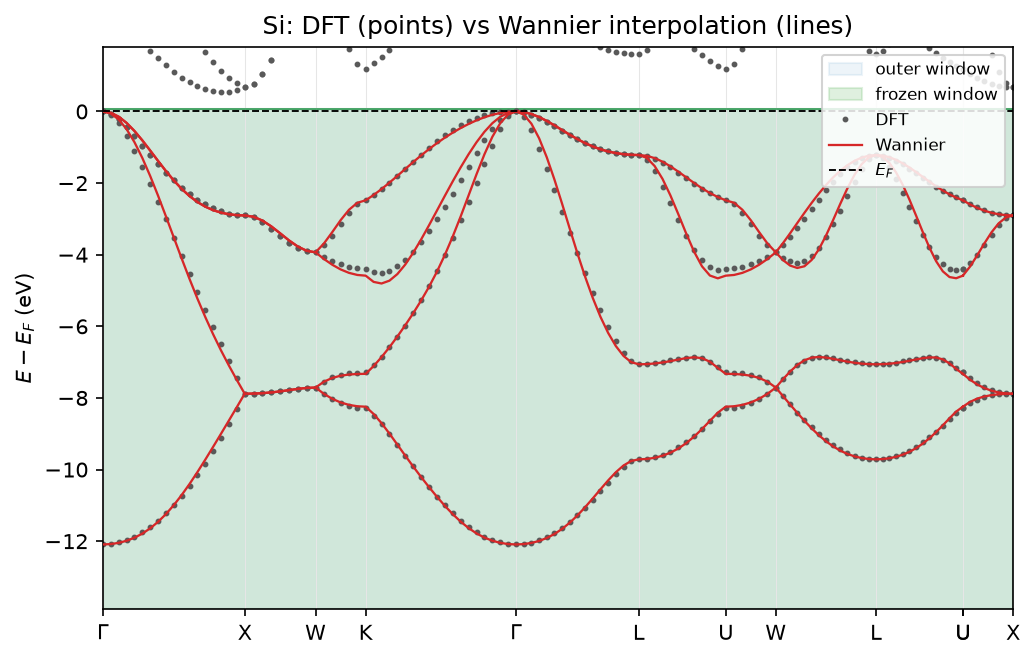

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 256 states


In [4]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov['fermi_energy']
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'si_selproj', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(-1e3, 6.5), frozen_window=(-1e3, 6.5), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Si: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=(-1e3, 6.5), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


**Takeaway.** The choice of trial orbitals (atom-centred $sp^3$ vs. bond-centred $s$) is a gauge choice within the same physical valence subspace — waw reproduces Wannier90's `select_projections` outcome directly, by specifying only the desired projection subset up front.